# Machine Learning Modeling Pipeline

In this phase, we build an end-to-end machine learning pipeline for predicting `SalePrice`. The workflow consists of the following steps:

1. **Feature Engineering & Preprocessing:** Create aggregated features, then handle missing values and encode categorical features with a `ColumnTransformer` (median imputation with indicators for numeric, ordinal and one-hot encoding for categorical features).
2. **Target Transformation:** Train on `log1p(SalePrice)` using `TransformedTargetRegressor`; predictions are converted back to dollars.
3. **Baseline Comparison:** Compare a `Dummy` baseline, linear models (Ridge, Lasso, ElasticNet) and boosting models (Gradient Boosting, XGBoost, LightGBM) with 5-fold cross-validation repeated 3 times.
4. **Hyperparameter Tuning:** Tune the three best baseline models with `RandomizedSearchCV` and select the one with the lowest CV RMSE.
5. **Final Evaluation:** Evaluate the selected model once on the untouched test set (MAE, RMSE, R², residual analysis) and inspect permutation importance.
6. **Final Training:** Retrain the selected pipeline on the full dataset and save it with `joblib`.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RepeatedKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid")


## 1. Feature Engineering and Train-Test Split

`engineer_features` applies the decisions made in the EDA:
* drops `Id` (no predictive value) and the near-constant columns `Street` and `Utilities`;
* converts `MSSubClass` to a categorical variable;
* creates `TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `HasGarage` and `HasPool`.

These transformations work row by row and learn nothing from the data, so applying them before the split does not cause data leakage. Everything that **is** learned from data (imputation values, category lists) lives inside the pipeline and is fitted on training data only. The data is split 80% / 20% with `random_state=42`.

In [ ]:
def engineer_features(data):
    df = data.copy()
    
    # 1. Drop identifiers and near-constant columns
    cols_to_drop = ['Id', 'Street', 'Utilities']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    # 2. Fix data types
    if 'MSSubClass' in df.columns:
        df['MSSubClass'] = df['MSSubClass'].astype(str)
        
    # 3. Create aggregated spatial & temporal features
    df['TotalSF'] = df.get('TotalBsmtSF', 0) + df.get('1stFlrSF', 0) + df.get('2ndFlrSF', 0)
    df['TotalBath'] = df.get('FullBath', 0) + 0.5 * df.get('HalfBath', 0) + df.get('BsmtFullBath', 0) + 0.5 * df.get('BsmtHalfBath', 0)
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    
    # 4. Boolean Flags
    df['HasGarage'] = (df.get('GarageArea', 0) > 0).astype(int)
    df['HasPool'] = (df.get('PoolArea', 0) > 0).astype(int)
    
    return df

raw_df = pd.read_csv('../data/raw/train.csv')
df = engineer_features(raw_df)

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Building the Preprocessing Pipeline

The `ColumnTransformer` contains three branches:
* **Numerical:** `SimpleImputer(strategy='median', add_indicator=True)`. The indicator columns mark values that were originally missing (e.g., `GarageYrBlt`, `LotFrontage`). No scaling is applied because the final candidates are tree-based models.
* **Ordinal:** `ExterQual`, `KitchenQual` and `HeatingQC` are encoded with the order `Po < Fa < TA < Gd < Ex`. Missing values are filled with `'TA'` and unseen categories are encoded as `-1`.
* **Nominal:** all remaining categorical columns are filled with the constant `'Missing'` and one-hot encoded (`handle_unknown='ignore'`).

In [34]:
# Identify feature types
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

# Define ordinal columns and their expected order
ordinal_cols = ['ExterQual', 'KitchenQual', 'HeatingQC']
cat_cols = [c for c in cat_cols if c not in ordinal_cols] # Nominal remaining

quality_levels = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_categories = [quality_levels] * len(ordinal_cols)

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median", add_indicator=True)),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='TA')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, cat_cols)
    ])

## 3. Baseline Model Comparison

Before tuning anything, we compare seven models with their default (or lightly set) parameters:
* `Dummy` (predicts the mean of the log-target) as the minimum reference,
* linear models: `Ridge`, `Lasso`, `ElasticNet`,
* boosting models: `Gradient Boosting`, `XGBoost`, `LightGBM`.

Every model is wrapped in `TransformedTargetRegressor` (`log1p` / `expm1`) and evaluated with `RepeatedKFold` (5 folds × 3 repeats). The RMSE is computed **after** the inverse transform, i.e., in dollars. We report the mean and the standard deviation across the 15 folds, because the spread is needed to judge whether differences between models are meaningful.

In [35]:
models = {
    'Dummy': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(alpha=0.001, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.001, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

# Repeated K-Fold for more robust variance estimation
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
baseline_results = {}

print("Evaluating Baselines (RMSE Mean ± Std):\n" + "-"*50)

for name, model in models.items():
    ttr = TransformedTargetRegressor(
        regressor=Pipeline(steps=[('preprocessor', preprocessor), ('model', model)]),
        func=np.log1p, inverse_func=np.expm1
    )
    
    # Calculate Cross-Validation RMSE
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(ttr, X_train, y_train, cv=rkf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    rmse_scores = -cv_scores
    baseline_results[name] = {'mean': rmse_scores.mean(), 'std': rmse_scores.std()}
    print(f"{name:<20}: {rmse_scores.mean():,.0f} $ ± {rmse_scores.std():,.0f} $")

Evaluating Baselines (RMSE Mean ± Std):
--------------------------------------------------
Dummy               : 78,247 $ ± 5,981 $
Ridge               : 49,557 $ ± 41,658 $
Lasso               : 50,770 $ ± 45,612 $
ElasticNet          : 49,153 $ ± 43,549 $
Gradient Boosting   : 26,696 $ ± 5,113 $
XGBoost             : 30,122 $ ± 5,846 $
LightGBM            : 27,325 $ ± 4,314 $


**Observations on the baselines:**
* All boosting models are far better than the `Dummy` baseline (≈ $78k): Gradient Boosting ($26.7k) and LightGBM ($27.3k) are the best, XGBoost with default parameters is behind ($30.1k). The gap between Gradient Boosting and LightGBM is smaller than one standard deviation (≈ $4-5k), so they are practically tied.
* The linear models have a CV RMSE of ≈ $49-51k with a standard deviation of ≈ $42-46k, which is almost as large as the mean. This means that some folds produce extremely large errors, so these numbers reflect an instability of the current setup (unscaled features, sensitivity to extreme observations after the inverse log transform), not the true capability of linear models. They should not be considered conclusively compared to the boosting models.

## 4. Hyperparameter Tuning for the Top 3 Models

The three best non-dummy models of the baseline comparison are selected automatically (currently Gradient Boosting, LightGBM and XGBoost). Each is tuned with `RandomizedSearchCV` using the same budget (**20 sampled combinations** out of a discrete space of 48) and the same `RepeatedKFold` (5 × 3). The search space focuses on regularization for a small dataset: shallow trees (`max_depth` 2-4), conservative learning rates (0.01 / 0.03), 500-1000 trees, and stochastic sampling (`subsample`, column sampling). The model with the lowest CV RMSE becomes the final model.

In [36]:
# Automatically select top 3 models excluding Dummy
sorted_models = sorted([(k, v['mean']) for k, v in baseline_results.items() if k != 'Dummy'], key=lambda x: x[1])
top_3_names = [m[0] for m in sorted_models[:3]]
print(f"Selected models for tuning: {top_3_names}")

# Define parameter grid strictly for the models that might be selected
param_dist = {
    'Ridge': {'regressor__model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'regressor__model__alpha': [0.0001, 0.001, 0.01, 0.1]},
    'Gradient Boosting': {
        'regressor__model__n_estimators': [500, 1000],
        'regressor__model__learning_rate': [0.01, 0.03],
        'regressor__model__max_depth': [2, 3, 4],
        'regressor__model__subsample': [0.8, 1.0],
        'regressor__model__max_features': [0.8, 1.0]
    },
    'XGBoost': {
        'regressor__model__n_estimators': [500, 1000],
        'regressor__model__learning_rate': [0.01, 0.03],
        'regressor__model__max_depth': [2, 3, 4],
        'regressor__model__subsample': [0.8, 1.0],
        'regressor__model__colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'regressor__model__n_estimators': [500, 1000],
        'regressor__model__learning_rate': [0.01, 0.03],
        'regressor__model__max_depth': [2, 3, 4],
        'regressor__model__subsample': [0.8, 1.0],
        'regressor__model__colsample_bytree': [0.8, 1.0]
    }
}

best_pipelines = {}
tuned_results = {}

for name in top_3_names:
    print(f"\nTuning {name}...")
    ttr = TransformedTargetRegressor(
        regressor=Pipeline(steps=[('preprocessor', preprocessor), ('model', models[name])]),
        func=np.log1p, inverse_func=np.expm1
    )
    
    random_search = RandomizedSearchCV(
        estimator=ttr, param_distributions=param_dist[name],
        n_iter=20, cv=rkf, scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    
    random_search.fit(X_train, y_train)
    best_pipelines[name] = random_search.best_estimator_
    tuned_results[name] = -random_search.best_score_
    print(f"Best CV RMSE: {tuned_results[name]:,.0f} $ | Params: {random_search.best_params_}")

best_model_name = min(tuned_results, key=tuned_results.get)
final_model = best_pipelines[best_model_name]
print(f"\nBest Performing Model: {best_model_name}")

Selected models for tuning: ['Gradient Boosting', 'LightGBM', 'XGBoost']

Tuning Gradient Boosting...
Best CV RMSE: 26,146 $ | Params: {'regressor__model__subsample': 1.0, 'regressor__model__n_estimators': 500, 'regressor__model__max_features': 0.8, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.03}

Tuning LightGBM...
Best CV RMSE: 26,406 $ | Params: {'regressor__model__subsample': 1.0, 'regressor__model__n_estimators': 1000, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.03, 'regressor__model__colsample_bytree': 0.8}

Tuning XGBoost...
Best CV RMSE: 26,218 $ | Params: {'regressor__model__subsample': 0.8, 'regressor__model__n_estimators': 500, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.03, 'regressor__model__colsample_bytree': 1.0}

Best Performing Model: Gradient Boosting


**Observations on tuning:**
* Tuning improved all three models: Gradient Boosting 26,146 $, XGBoost 26,218 $, LightGBM 26,406 $ (CV RMSE).
* The differences between the three tuned models (≈ $70 between the first and second, ≈ $260 between the first and third) are tiny compared with the fold-to-fold standard deviation (≈ $4-5k), so the ranking is **not statistically meaningful**; Gradient Boosting is selected only because it has the lowest mean.
* For all three models the selected `learning_rate` (0.03) is the largest value in the search space, and `n_estimators` is at an edge of its range (500 for Gradient Boosting and XGBoost, 1000 for LightGBM), which suggests that the search space could be widened.

## 5. Final Evaluation on the Test Set

The selected model is now evaluated **once** on the unseen test set (`X_test`, 292 houses). We report MAE, RMSE and R², and examine the actual-vs-predicted and residual plots.

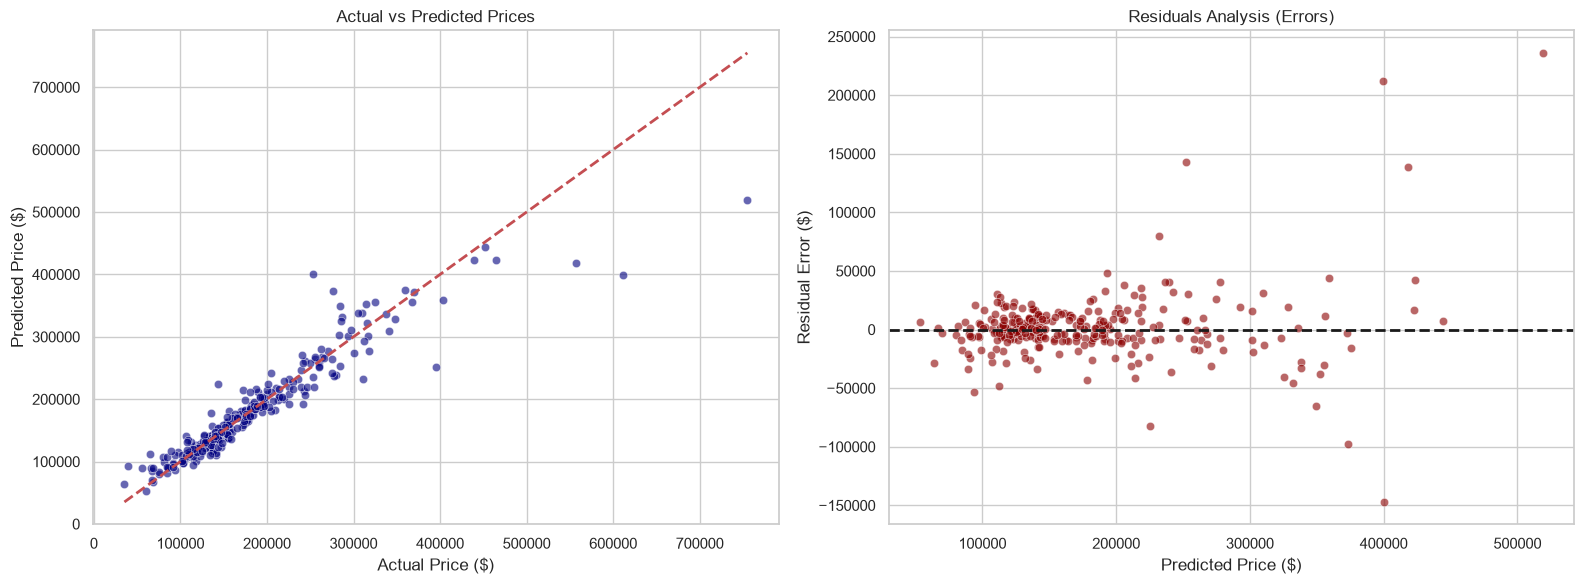

Test MAE   : 15,807 $
Test RMSE  : 30,100 $
Test R2    : 0.8819


In [37]:
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=axes[0], color='navy')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

# Residuals Plot
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[1], color='darkred')
axes[1].axhline(0, color='k', linestyle='--', lw=2)
axes[1].set_title('Residuals Analysis (Errors)')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual Error ($)')

plt.tight_layout()
plt.show()

# Reporting Metrics
print(f"Test MAE   : {mean_absolute_error(y_test, y_pred):,.0f} $")
print(f"Test RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} $")
print(f"Test R2    : {r2_score(y_test, y_pred):.4f}")

**Observations on the test set:**
* Test MAE is 15,807 $, RMSE is 30,100 $ and R² is 0.8819. The test RMSE is higher than the CV RMSE of the selected model (26,146 $).
* The plots show why: for most houses (≈ up to $300k) the predictions are tight, but the largest errors (residuals of roughly $100-235k) come from a handful of expensive homes that are underpredicted (e.g., an actual price of ≈ $750k predicted as ≈ $520k). The residual spread grows with price (funnel shape).
* RMSE is dominated by these few points, and with only 292 test samples a single split is a noisy estimate. MAE is a more representative summary of the typical error.

## 6. Feature Importance, Final Retraining and Saving

* **Permutation importance** is computed on the test set with the full pipeline, so it measures how much the score drops when a **raw input column** is shuffled (one-hot columns are therefore not split up). The ten most important columns are plotted.
* After the evaluation is finished, the selected pipeline is **retrained on the whole dataset** (train + test) and saved with `joblib`. This final model cannot be evaluated any more, so its quality is the one measured in Section 5.
* **Note:** `engineer_features` is not part of the saved pipeline. The saved model expects input that has already gone through `engineer_features`.

In [38]:
# Permutation Importance (evaluated on test set)
print("Calculating Permutation Importance...")
result = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()[-10:] # Top 10 features
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.show()

# Retrain on the entire dataset and save the model
print("Retraining best model on full dataset for production...")
final_model.fit(X, y)
joblib.dump(final_model, 'ames_housing_model.pkl')
print("Model saved to 'ames_housing_model.pkl'. Ready for deployment!")

Calculating Permutation Importance...


TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 1000x600 with 0 Axes>

## Limitations and Possible Next Steps
* The linear baselines are unstable (very high fold variance); they need scaling and a closer look at extreme observations before they can be compared fairly with the boosting models.
* The very large but low-priced houses identified in the EDA are still in the training data.
* The tuned models are statistically tied, and the best hyperparameters lie at the edge of the search space.
* The test RMSE comes from a single 292-sample split and is dominated by a few expensive homes.